In [1]:
# importing libraries
import pandas as pd
import numpy as np
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
#loasing our mergerd data "composite_pool" and "triangulated NFA monthly data"
df_pool = pd.read_csv('composite_pool.csv')
df_nfa_tri = pd.read_csv('NFA_Monthly_Triangulated.csv')


In [3]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import xgboost as xgb
import numpy as np

In [4]:

# TIMELINE PARTITIONING & LEAKAGE-FREE FEATURE ENGINEERING
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# THE FIX: Create the master dataframe grid safely via inner join
master_df = pd.merge(df_nfa_tri, df_pool, on=['COUNTRY', 'Date'], how='inner')

master_df['Date'] = pd.to_datetime(master_df['Date'])
master_df = master_df.sort_values(by=['COUNTRY', 'Date']).reset_index(drop=True)

# 1. INITIAL CHRONOLOGICAL SEPARATION
train_df = master_df[master_df['Date'].dt.year <= 2021].copy()
test_df = master_df[master_df['Date'].dt.year > 2021].copy()

# 2. ISOLATED FEATURE ENGINEERING ENGINE
def build_features(df, is_train=True, scaler_obj=None, pca_obj=None):
    df = df.copy()
    
    # Pre-requisite: Trade Balance
    if 'Trade_Balance' not in df.columns and 'Exports of goods' in df.columns:
        df['Trade_Balance'] = df['Exports of goods'] - df['Imports of goods']
        
    # Sovereign Solvency and Vulnerability Ratios
    df['NFA_to_GDP_Ratio'] = np.where(df['GDP'] > 0, df['NFA_Triangulated'] / df['GDP'], np.nan)
    df['Import_Cover_Months'] = np.where(df['Imports of goods'] > 0, df['NFA_Triangulated'] / df['Imports of goods'], np.nan)
    df['Debt_Coverage_Ratio'] = np.where(df['External_Debt'] > 0, df['NFA_Triangulated'] / df['External_Debt'], np.nan)
    df['Debt_to_GDP_Ratio'] = np.where(df['GDP'] > 0, df['External_Debt'] / df['GDP'], np.nan)
    df['Trade_Balance_to_GDP'] = np.where(df['GDP'] > 0, df['Trade_Balance'] / df['GDP'], np.nan)
    
    # Time-Series Trajectories (Safely isolated within Country groupings)
    df['NFA_Debt_Velocity'] = np.where(df.groupby('COUNTRY')['External_Debt'].diff(3) != 0, 
                                       df.groupby('COUNTRY')['NFA_Triangulated'].diff(3) / df.groupby('COUNTRY')['External_Debt'].diff(3), np.nan)
    df['Real_Capital_Drain'] = df['FEDFUNDS'] - df['CPI_VALUE']
    
    # Rolling Window Averages 
    rolling_fed = df.groupby('COUNTRY')['FEDFUNDS'].transform(lambda x: x.rolling(6, min_periods=1).mean())
    df['Fed_Rate_Momentum'] = df['FEDFUNDS'] - rolling_fed
    
    # Grouped Global Momentum (Prevents cross-country row contamination)
    df['Gold_3M_Change'] = df.groupby('COUNTRY')['Gold_Price'].pct_change(periods=3)
    df['DXY_3M_Change'] = df.groupby('COUNTRY')['DXY_Index'].pct_change(periods=3)
    df['Oil_Sensitivity_Index'] = np.where(df['Crude_Oil_Price'] > 0, df['Trade_Balance'] / df['Crude_Oil_Price'], np.nan)
    df['Gold_to_Debt_Ratio'] = np.where(df['External_Debt'] > 0, df['Gold_Price'] / df['External_Debt'], np.nan)
    
    # Statistical Anomaly Z-Scores
    rolling_mean_nfa = df.groupby('COUNTRY')['NFA_Triangulated'].transform(lambda x: x.rolling(12, min_periods=3).mean())
    rolling_std_nfa = df.groupby('COUNTRY')['NFA_Triangulated'].transform(lambda x: x.rolling(12, min_periods=3).std())
    df['NFA_Z_Score'] = np.where(rolling_std_nfa > 0, (df['NFA_Triangulated'] - rolling_mean_nfa) / rolling_std_nfa, np.nan)
    df['Exchange_Rate_Volatility'] = df.groupby('COUNTRY')['Exchange_Rate'].transform(lambda x: x.rolling(3, min_periods=2).std())
    
    # Target Variable Generation (the Answer Key for our model-exchange rates)
    df['Future_Exchange_Rate_3M'] = df.groupby('COUNTRY')['Exchange_Rate'].shift(-3)
    df['Exchange_Rate_Change'] = (df['Future_Exchange_Rate_3M'] - df['Exchange_Rate']) / df['Exchange_Rate']
    df['Crisis_Target'] = np.where(df['Exchange_Rate_Change'] >= 0.05, 1, 0)
    df['Crisis_Target'] = np.where(df['Future_Exchange_Rate_3M'].isna(), np.nan, df['Crisis_Target'])
    
    # AIRTIGHT PCA INDEX GENERATION
    pca_features = ['Monthly_Avg_VIXCLS', 'FEDFUNDS', 'Crude_Oil_Price']
    if 'DXY_Index' in df.columns: pca_features.append('DXY_Index')
    
    valid_mask = df[pca_features].notna().all(axis=1)
    if valid_mask.sum() > 0:
        if is_train:
            scaler_obj = StandardScaler()
            pca_obj = PCA(n_components=1)
            scaled = scaler_obj.fit_transform(df.loc[valid_mask, pca_features])
            scores = pca_obj.fit_transform(scaled).flatten()
        else:
            scaled = scaler_obj.transform(df.loc[valid_mask, pca_features])
            scores = pca_obj.transform(scaled).flatten()
            
        df.loc[valid_mask, 'Synthetic_Stress_Index'] = scores
    else:
        df['Synthetic_Stress_Index'] = np.nan
        
    return df, scaler_obj, pca_obj



In [5]:
# 3. RUN THE CLEAN ISOLATED PIPELINES
train_feat, scaler, pca = build_features(train_df, is_train=True)
test_feat, _, _ = build_features(test_df, is_train=False, scaler_obj=scaler, pca_obj=pca)

# 4. DROP THE TARGET NA LINES POST-PROCESSING
train_clean = train_feat.dropna(subset=['Crisis_Target'])
test_clean = test_feat.dropna(subset=['Crisis_Target'])

# 5. LOCK IN FEATURES AND TARGET SEPARATIONS
features = [
    'Monthly_Avg_VIXCLS', 'FEDFUNDS', 'CPI_VALUE', 'Crude_Oil_Price',
    'NFA_to_GDP_Ratio', 'Import_Cover_Months', 'Debt_Coverage_Ratio', 
    'Debt_to_GDP_Ratio', 'Trade_Balance_to_GDP', 'NFA_Debt_Velocity',
    'Real_Capital_Drain', 'Fed_Rate_Momentum', 'Oil_Sensitivity_Index', 
    'Gold_to_Debt_Ratio', 'NFA_Z_Score', 'Exchange_Rate_Volatility',
    'Synthetic_Stress_Index', 'Gold_3M_Change', 'DXY_3M_Change'
]

X_train = train_clean[features]
y_train = train_clean['Crisis_Target']
X_test = test_clean[features]
y_test = test_clean['Crisis_Target']

ratio = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Isolated Feature Arrays Built! Row sizes matched completely.")
print(f"Training Matrix Shape: {X_train.shape} | Testing Matrix Shape: {X_test.shape}")

Isolated Feature Arrays Built! Row sizes matched completely.
Training Matrix Shape: (32184, 19) | Testing Matrix Shape: (5319, 19)


In [6]:

# 6. EXPORT THE FINAL PIPELINE MATRIX 
print("💾 Stitching clean partitions and exporting checkpoint...")

# Safely recombine the strictly engineered train and test sets
final_master_df = pd.concat([train_clean, test_clean]).sort_values(by=['COUNTRY', 'Date']).reset_index(drop=True)

# Export to CSV for manual auditing and dashboard tracebacks
final_master_df.to_csv("final_master_df.csv", index=False)

print(f"'final_master_df.csv' successfully saved to your folder! Total Rows: {len(final_master_df)}")
print(final_master_df.columns)

💾 Stitching clean partitions and exporting checkpoint...
'final_master_df.csv' successfully saved to your folder! Total Rows: 37503
Index(['Date', 'NFA_Triangulated', 'COUNTRY', 'Exchange_Rate', 'CPI_VALUE',
       'Export price index (EPI)', 'Exports of goods',
       'Exports of goods, Price deflator', 'Exports of goods, Volume index',
       'Import price index', 'Imports of goods',
       'Imports of goods, Price deflator', 'Imports of goods, Volume index',
       'External_Debt', 'GDP', 'BOP_USD', 'FEDFUNDS', 'Monthly_Avg_VIXCLS',
       'DXY_Index', 'Crude_Oil_Price', 'Gold_Price', 'COFER_Reserves',
       'Trade_Balance', 'NFA_to_GDP_Ratio', 'Import_Cover_Months',
       'Debt_Coverage_Ratio', 'Debt_to_GDP_Ratio', 'Trade_Balance_to_GDP',
       'NFA_Debt_Velocity', 'Real_Capital_Drain', 'Fed_Rate_Momentum',
       'Gold_3M_Change', 'DXY_3M_Change', 'Oil_Sensitivity_Index',
       'Gold_to_Debt_Ratio', 'NFA_Z_Score', 'Exchange_Rate_Volatility',
       'Future_Exchange_Rate_3M', '

In [7]:
model = xgb.XGBClassifier(
    n_estimators=300,        # How many decision trees to build
    max_depth=5,             # How deep the trees can think
    learning_rate=0.05,      # How fast it learns (slower prevents overfitting)
    scale_pos_weight=ratio,  # Forces the AI to pay extreme attention to Crises!
    random_state=42,
    eval_metric='auc',
    missing=np.nan           # Explicitly telling XGBoost "Don't panic if you see a NaN"
)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [8]:
#PREDICT AND EVALUATE ON THE 2022-2024
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1] # The exact percentage probability of a crash

In [9]:
print(classification_report(y_test, predictions, target_names=['Safe (0)', 'Crisis (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, probabilities):.4f}")

              precision    recall  f1-score   support

    Safe (0)       0.90      0.97      0.93      4711
  Crisis (1)       0.43      0.20      0.27       608

    accuracy                           0.88      5319
   macro avg       0.67      0.58      0.60      5319
weighted avg       0.85      0.88      0.86      5319

ROC-AUC Score: 0.7435


In [10]:
#PHASE 5: HYPERPARAMETER TUNING (RANDOMIZED SEARCH)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
import numpy as np


In [11]:
# 1. Define the grid of brain configurations to test
param_grid = {
    'max_depth': [3, 4, 5, 6],               # How deep the logic goes
    'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05],   # How fast it updates its beliefs
    'n_estimators': [100, 200, 300, 500, 700, 900],       # Number of trees in the forest
    'subsample': [0.6, 0.8, 1.0, 1.1, 1.2],               # Prevents memorizing specific rows
    'colsample_bytree': [0.6, 0.8, 1.0, 1.1, 1.2]         # Forces the AI to use all features
}

In [12]:
# 2. Initialize the base model with our mandatory safety constraints
base_model = xgb.XGBClassifier(
    scale_pos_weight=ratio, 
    eval_metric='auc', 
    missing=np.nan,
    random_state=42
)

In [13]:
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=3, 
    verbose=1,
    random_state=42,
    n_jobs=-1 # Uses all processor cores to speed up execution
)
print("RandomizedSearchCV Search Engine Successfully Restored!")

RandomizedSearchCV Search Engine Successfully Restored!


In [14]:
print("Testing 50 different AI configurations.")
random_search.fit(X_train, y_train)

Testing 50 different AI configurations.
Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [15]:
# 4. Extract the ultimate winner
for key, value in random_search.best_params_.items():
    print(f" - {key}: {value}")

 - subsample: 0.6
 - n_estimators: 300
 - max_depth: 4
 - learning_rate: 0.04
 - colsample_bytree: 1.0


In [16]:
# 5. Evaluate the optimized model on the unseen 2022-2024 Test Set
best_model = random_search.best_estimator_
opt_predictions = best_model.predict(X_test)
opt_probabilities = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, opt_predictions, target_names=['Safe (0)', 'Crisis (1)']))
print(f"Optimized ROC-AUC Score: {roc_auc_score(y_test, opt_probabilities):.4f}")

              precision    recall  f1-score   support

    Safe (0)       0.91      0.96      0.93      4711
  Crisis (1)       0.41      0.25      0.31       608

    accuracy                           0.87      5319
   macro avg       0.66      0.60      0.62      5319
weighted avg       0.85      0.87      0.86      5319

Optimized ROC-AUC Score: 0.7928


In [17]:

# MONTH MULTI-HORIZON REGRESSION ENGINE (DIRECT MULTI-STEP)
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import pickle

print("Activating Stage-2: 12-Month Multi-Horizon Forecaster...")

# Force the exact 19 feature schema to match your final_master_df
features = [
    'Monthly_Avg_VIXCLS', 'FEDFUNDS', 'CPI_VALUE', 'Crude_Oil_Price',
    'NFA_to_GDP_Ratio', 'Import_Cover_Months', 'Debt_Coverage_Ratio', 
    'Debt_to_GDP_Ratio', 'Trade_Balance_to_GDP', 'NFA_Debt_Velocity',
    'Real_Capital_Drain', 'Fed_Rate_Momentum', 'Oil_Sensitivity_Index', 
    'Gold_to_Debt_Ratio', 'NFA_Z_Score', 'Exchange_Rate_Volatility',
    'Synthetic_Stress_Index', 'Gold_3M_Change', 'DXY_3M_Change'
]

# 1. Initialize storage for the 12 distinct AI Models
horizon_models = {}
mae_results = {}

# 2. Iterate through months 1 to 12
for i in range(1, 13):
    print(f"Compiling and Training Horizon: T+{i} Months...")
    target_col = f'Target_Pct_Change_{i}M'
    
    # Calculate the exact historical percentage change for this specific timeframe
    train_clean[target_col] = train_clean.groupby('COUNTRY')['Exchange_Rate'].shift(-i)
    train_clean[target_col] = (train_clean[target_col] - train_clean['Exchange_Rate']) / train_clean['Exchange_Rate']
    
    test_clean[target_col] = test_clean.groupby('COUNTRY')['Exchange_Rate'].shift(-i)
    test_clean[target_col] = (test_clean[target_col] - test_clean['Exchange_Rate']) / test_clean['Exchange_Rate']
    
    # Drop rows where the future horizon is unknown (end of the dataset)
    valid_train = train_clean.dropna(subset=[target_col] + features)
    valid_test = test_clean.dropna(subset=[target_col] + features)
    
    X_train_h = valid_train[features]
    y_train_h = valid_train[target_col]
    X_test_h = valid_test[features]
    y_test_h = valid_test[target_col]
    
    # Train robust pseudo-huber regressor to insulate against massive crash outliers
    reg_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=2.0,
        reg_lambda=5.0,
        objective='reg:pseudohubererror', # <--- Massive accuracy boost for financial quant data
        missing=np.nan,
        random_state=42
    )
    
    reg_model.fit(X_train_h, y_train_h)
    horizon_models[f'M{i}'] = reg_model
    
    # Evaluate MAE
    pred_h = reg_model.predict(X_test_h)
    mae_results[f'M{i}'] = mean_absolute_error(y_test_h, pred_h)

print("\n All 12 Horizon Models Trained Successfully!")

# 3. Print the Accuracy Decay Matrix
print("\n HORIZON ACCURACY DECAY MATRIX (Mean Absolute Error in %)")
print("-" * 55)
for k, v in mae_results.items():
    print(f"Horizon {k}: Expected error margin of +/- {v*100:.2f}%")

# 4. Save the master dictionary of models for the Streamlit App
with open('xg_12m_regressors.pkl', 'wb') as f:
    pickle.dump(horizon_models, f)
print("\n 'xg_12m_regressors.pkl' compiled and saved for Dashboard Integration.")

Activating Stage-2: 12-Month Multi-Horizon Forecaster...
Compiling and Training Horizon: T+1 Months...
Compiling and Training Horizon: T+2 Months...
Compiling and Training Horizon: T+3 Months...
Compiling and Training Horizon: T+4 Months...
Compiling and Training Horizon: T+5 Months...
Compiling and Training Horizon: T+6 Months...
Compiling and Training Horizon: T+7 Months...
Compiling and Training Horizon: T+8 Months...
Compiling and Training Horizon: T+9 Months...
Compiling and Training Horizon: T+10 Months...
Compiling and Training Horizon: T+11 Months...
Compiling and Training Horizon: T+12 Months...

 All 12 Horizon Models Trained Successfully!

 HORIZON ACCURACY DECAY MATRIX (Mean Absolute Error in %)
-------------------------------------------------------
Horizon M1: Expected error margin of +/- 1.28%
Horizon M2: Expected error margin of +/- 2.24%
Horizon M3: Expected error margin of +/- 3.02%
Horizon M4: Expected error margin of +/- 3.42%
Horizon M5: Expected error margin of +/

 Initializing SHAP Game-Theory Explainability...


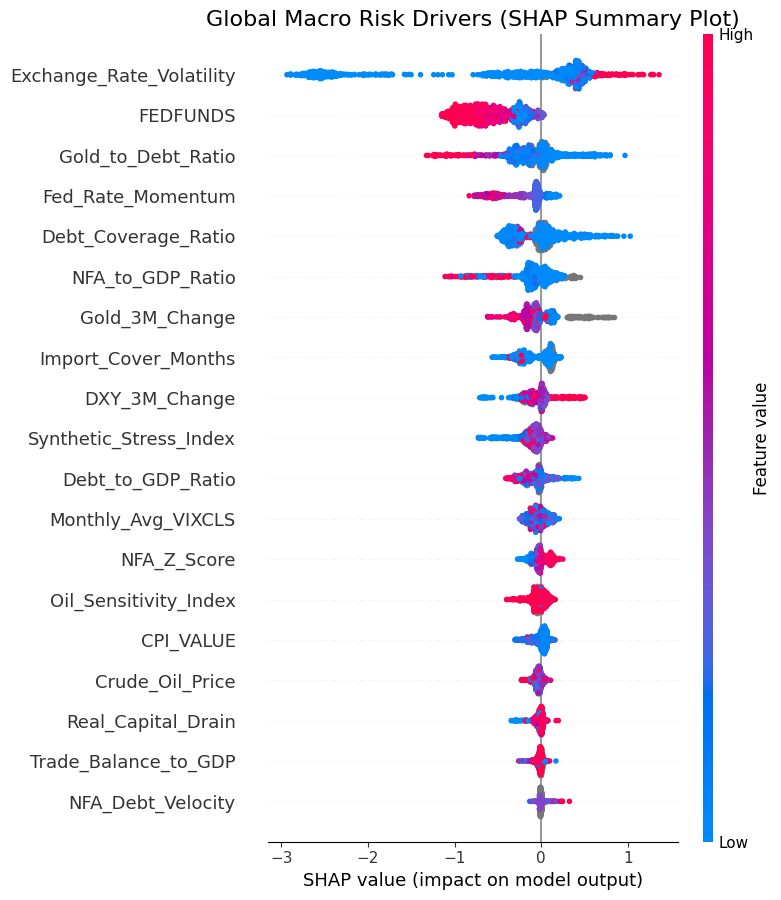


 Running a Local Autopsy on a High-Risk Prediction...
 TARGET IDENTIFIED: Türkiye in 2024-08
AI Predicted Probability of Crash: 87.15%
Did it actually crash 3 months later?: YES (Target 1)


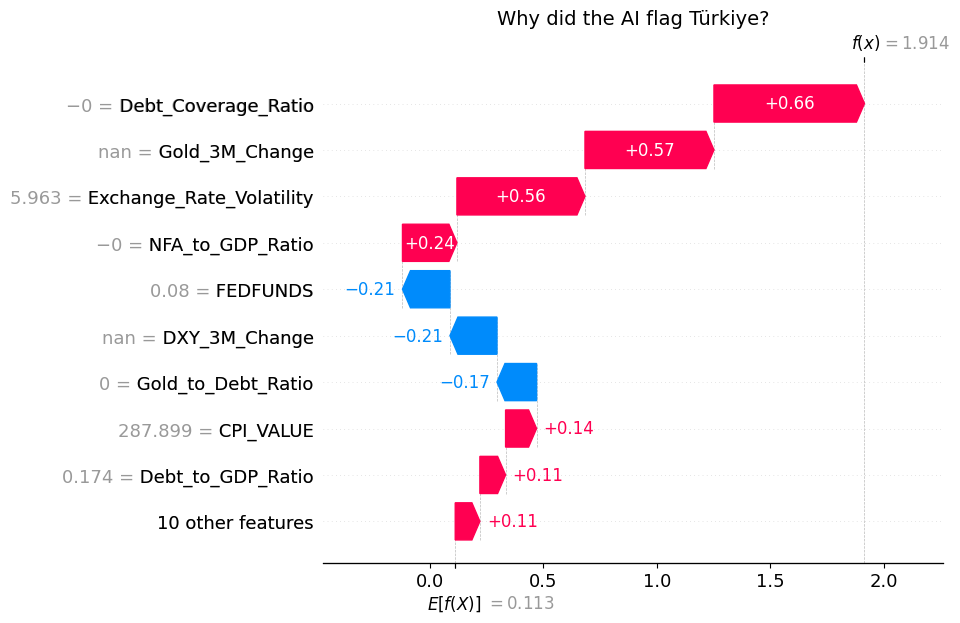

In [18]:

# PHASE 6: SHAP EXPLAINABILITY 
import shap
import matplotlib.pyplot as plt

print(" Initializing SHAP Game-Theory Explainability...")

# 1. Initialize the SHAP Explainer using your Optimized Model
# We use a sample of X_test to keep the computation extremely fast
X_test_sample = X_test.sample(n=1000, random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

# -------------------------------------------------------------
# PLOT 1: THE GLOBAL MACRO SUMMARY (What the AI cares about)
# -------------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.title("Global Macro Risk Drivers (SHAP Summary Plot)", fontsize=16)
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# PLOT 2: THE "AUTOPSY" (Explaining a specific prediction)
# -------------------------------------------------------------
print("\n Running a Local Autopsy on a High-Risk Prediction...")

# Find the row in our test set that the AI was MOST confident was going to crash
# (Highest probability of a crisis)
most_vulnerable_index = opt_probabilities.argmax()
vulnerable_row = X_test.iloc[[most_vulnerable_index]]

# Get the probability and the actual country/date details
prob = opt_probabilities[most_vulnerable_index]
actual_outcome = y_test.iloc[most_vulnerable_index]

# We must map this back to the original master_df to see WHICH country it was
vulnerable_metadata = test_df.iloc[most_vulnerable_index]
country_name = vulnerable_metadata['COUNTRY']
crash_date = vulnerable_metadata['Date'].strftime('%Y-%m')

print(f" TARGET IDENTIFIED: {country_name} in {crash_date}")
print(f"AI Predicted Probability of Crash: {prob*100:.2f}%")
print(f"Did it actually crash 3 months later?: {'YES (Target 1)' if actual_outcome == 1 else 'NO (False Alarm)'}")

# Generate the visual breakdown for THIS SPECIFIC PREDICTION
shap_values_local = explainer.shap_values(vulnerable_row)

plt.figure(figsize=(10, 4))
plt.title(f"Why did the AI flag {country_name}?", fontsize=14)
shap.waterfall_plot(shap.Explanation(values=shap_values_local[0], 
                                     base_values=explainer.expected_value, 
                                     data=vulnerable_row.iloc[0], 
                                     feature_names=features))
plt.show()

📊 Generating Executive Macro-Visuals and Diagnostics Matrix...


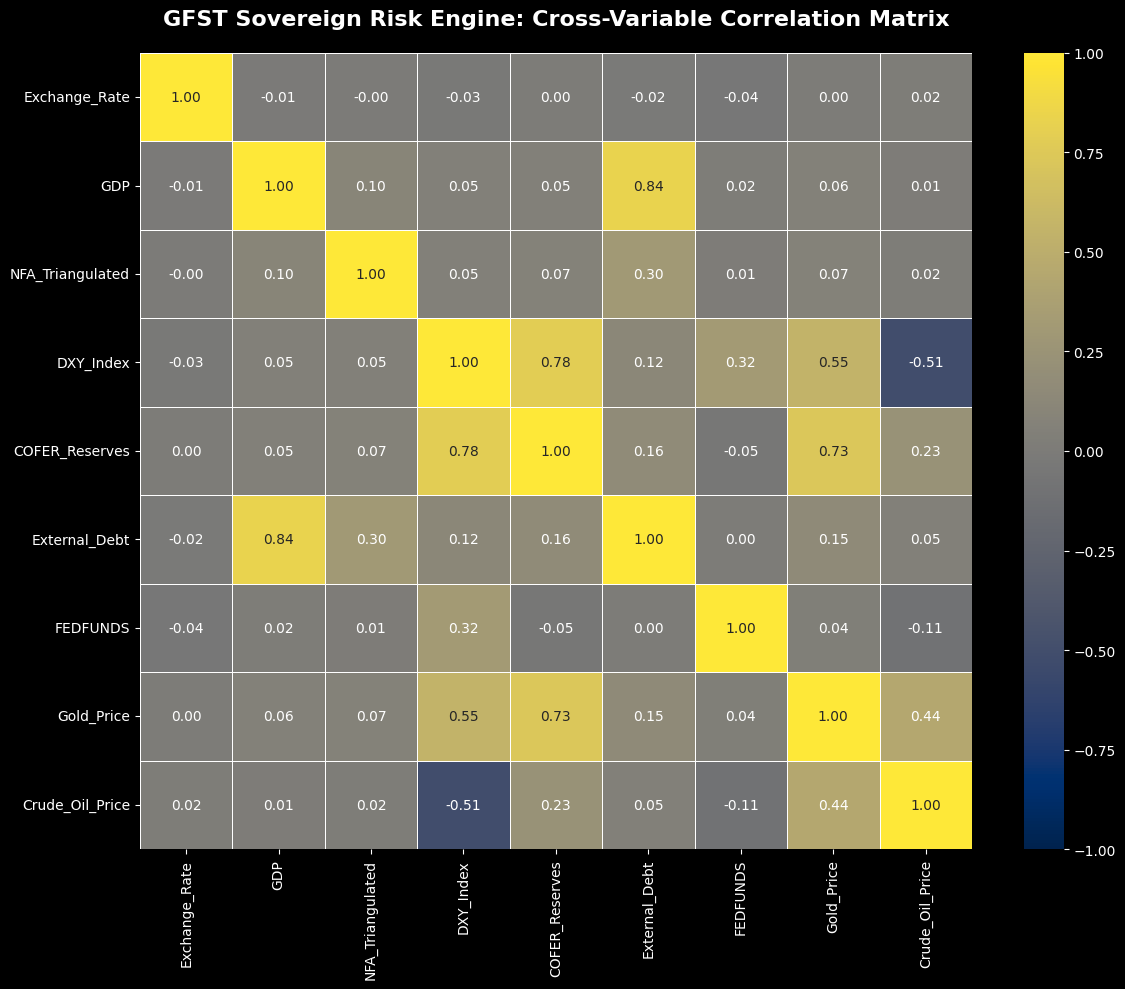

 Generating Country-Specific Macro Infographics for: India...


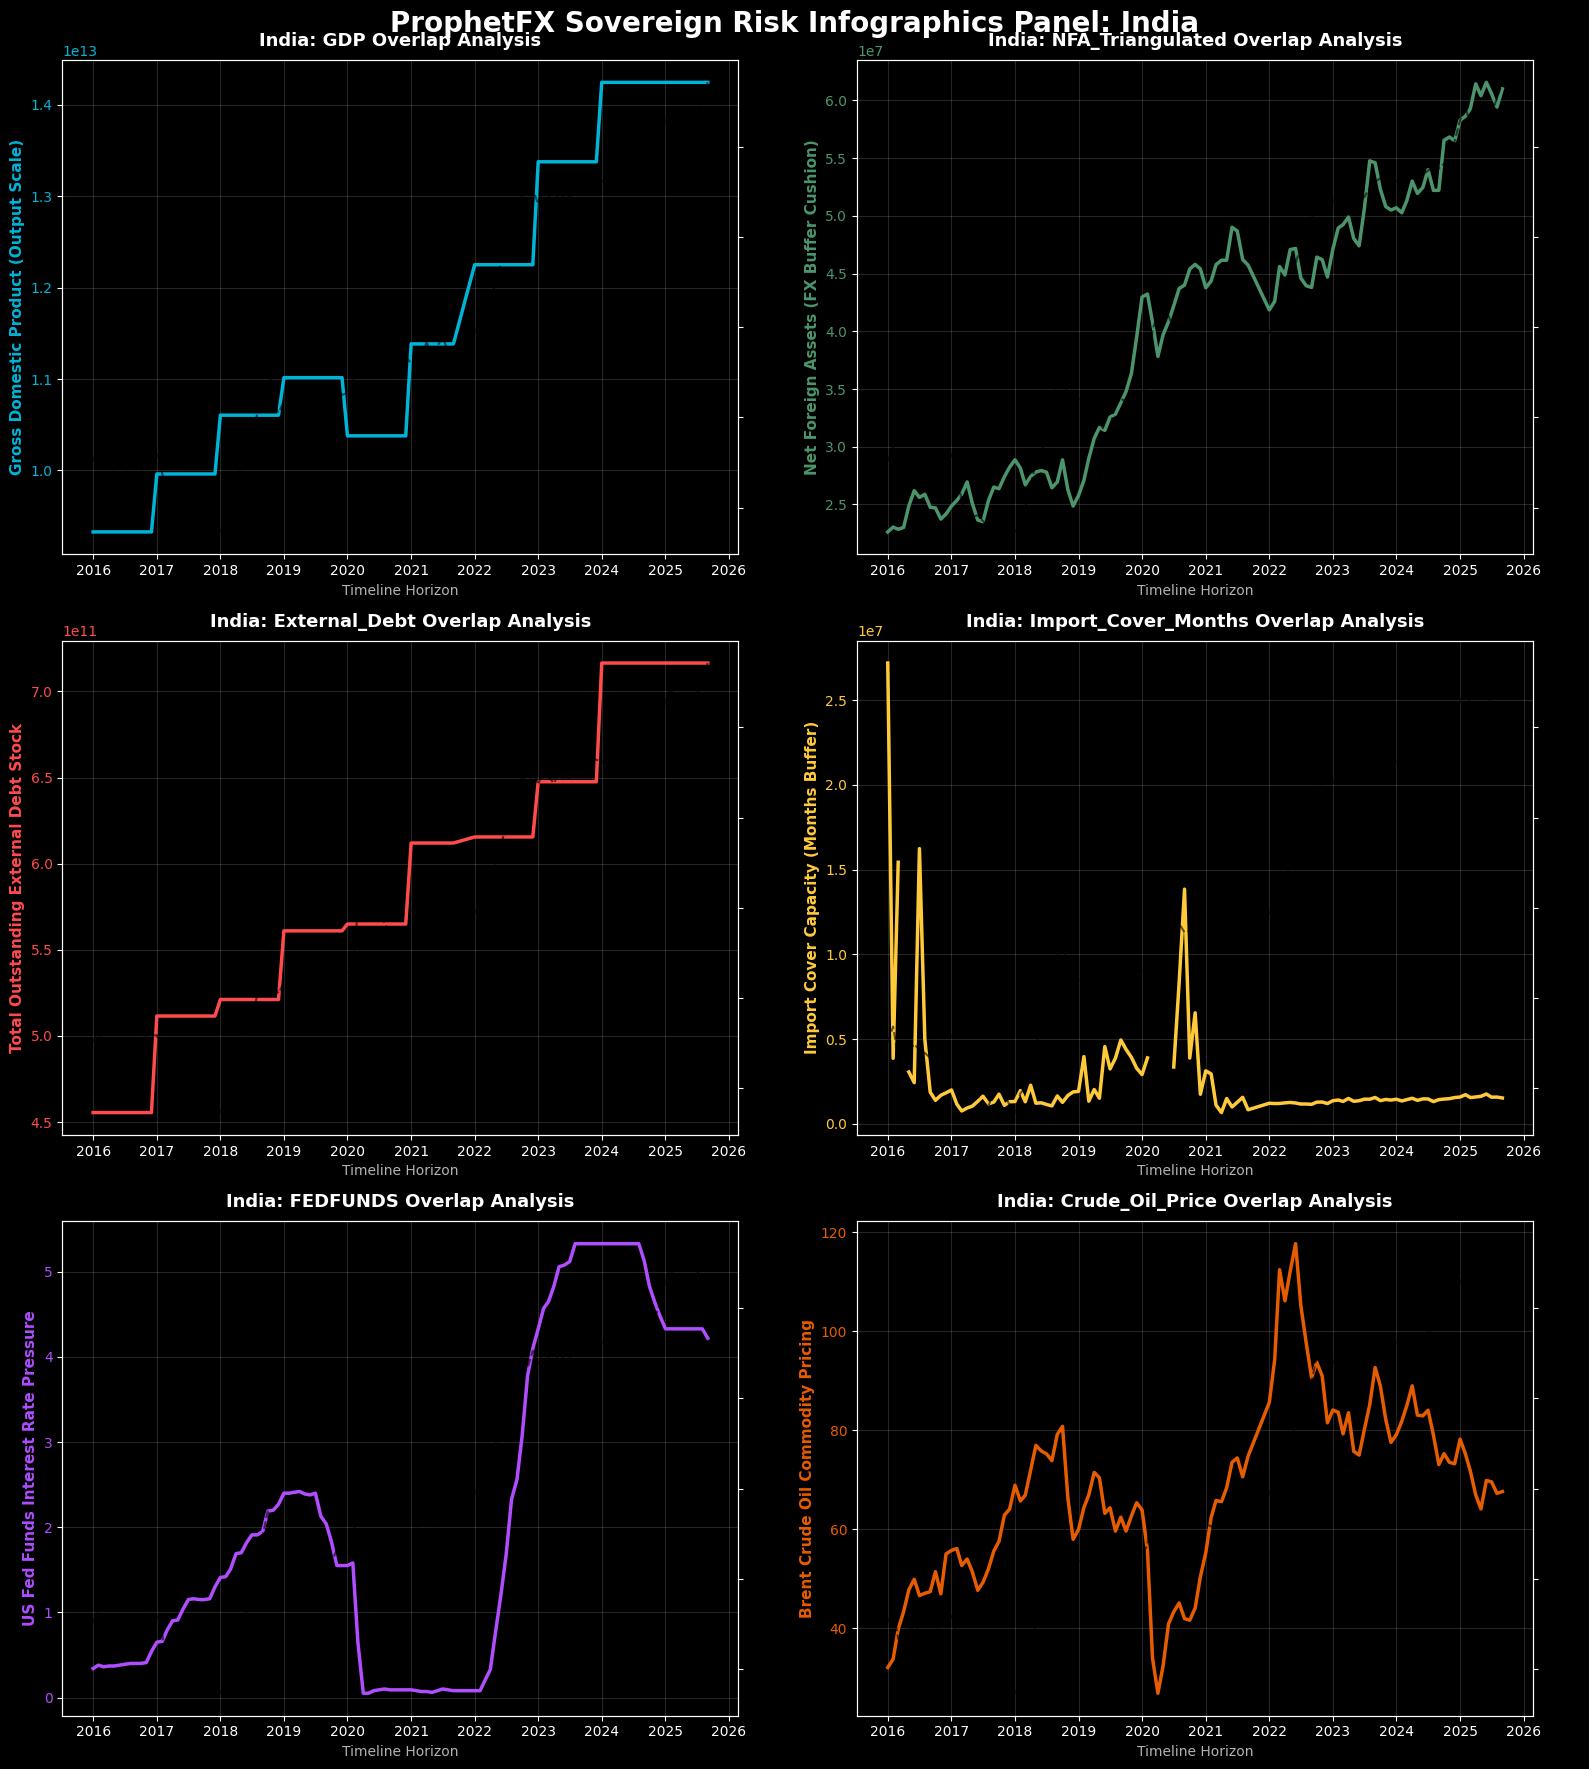

In [22]:

# MACROECONOMIC VISUAL DIAGNOSTICS & CORRELATION HEATMAP
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("📊 Generating Executive Macro-Visuals and Diagnostics Matrix...")

# 1. Isolate the exact variables we want to audit against our target
matrix_cols = [
    'Exchange_Rate', 'GDP', 'NFA_Triangulated', 'Balance_of_Payments', 
    'DXY_Index', 'COFER_Reserves', 'External_Debt', 'FEDFUNDS', 
    'Gold_Price', 'Crude_Oil_Price', 'Trade_Balance', 'Crisis_Target'
]

# Intersect with columns that actually exist in your dataframe to avoid any missing column errors
available_cols = [col for col in matrix_cols if col in master_df.columns]

# Calculate the full statistical Pearson correlation matrix
corr_matrix = master_df[available_cols].corr()

# PLOT 1: THE MASTER CORRELATION HEATMAP
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,              # Print the exact correlation number in each box
    cmap='cividis',          # High-contrast palette for perfect executive clarity
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1.0, vmax=1.0      # Lock the scale limits from perfect negative to positive
)
plt.title("GFST Sovereign Risk Engine: Cross-Variable Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# PHASE 8: EXECUTIVE SOVEREIGN MICRO-DIAGNOSTICS PANEL
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# CHOOSE YOUR TARGET TARGET COUNTRY FOR THE DIAGNOSTIC SLIDE
# Options: 'India', 'Turkey', 'Argentina', 'Egypt', 'Brazil', etc.
target_presentation_country = "India" 

print(f" Generating Country-Specific Macro Infographics for: {target_presentation_country}...")

# 1. Filter the master dataframe to isolate our target country cleanly
country_df = final_master_df[final_master_df['COUNTRY'] == target_presentation_country].sort_values('Date').copy()

if len(country_df) == 0:
    print(f" Warning: '{target_presentation_country}' not found in final_master_df. Check naming syntax.")
else:
    # 2. Set up a professional 3x2 grid of key vulnerability metrics
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    plt.style.use('dark_background') # Force a clean executive theme
    
    # List of metrics to evaluate side-by-side with the currency value
    macro_metrics = [
        ('GDP', 'Gross Domestic Product (Output Scale)','#00b4d8'),
        ('NFA_Triangulated', 'Net Foreign Assets (FX Buffer Cushion)', '#4c956c'),
        ('External_Debt', 'Total Outstanding External Debt Stock', '#ff4b4b'),
        ('Import_Cover_Months', 'Import Cover Capacity (Months Buffer)', '#ffca3a'),
        ('FEDFUNDS', 'US Fed Funds Interest Rate Pressure', '#af4dff'),
        ('Crude_Oil_Price', 'Brent Crude Oil Commodity Pricing', '#e65c00')
    ]
    
    axes = axes.flatten()
    
    for idx, (col_name, label_title, theme_color) in enumerate(macro_metrics):
        if col_name in country_df.columns:
            ax1 = axes[idx]
            
            # Line 1: Plot the Macro Parameter on the Left Axis
            line1 = ax1.plot(country_df['Date'], country_df[col_name], color=theme_color, linewidth=2.5, label=col_name)
            ax1.set_ylabel(label_title, color=theme_color, fontsize=11, fontweight='bold')
            ax1.tick_params(axis='y', labelcolor=theme_color)
            ax1.grid(True, alpha=0.15)
            
            # Line 2: Create a twin axis to map the Exchange Rate on the Right Axis
            ax2 = ax1.twinx()
            line2 = ax2.plot(country_df['Date'], country_df['Exchange_Rate'], color='Black', linewidth=1.5, linestyle='--', alpha=0.6, label='USD Spot')
            ax2.set_ylabel("Exchange Rate (Local per USD)", color='Black', fontsize=10, alpha=0.7)
            ax2.tick_params(axis='y', labelcolor='black')
            
            # Formatting title blocks cleanly
            ax1.set_title(f"{target_presentation_country}: {col_name} Overlap Analysis", fontsize=13, fontweight='bold', pad=10)
            ax1.set_xlabel("Timeline Horizon", fontsize=10, alpha=0.7)
        else:
            axes[idx].text(0.5, 0.5, f"Column '{col_name}'\nNot present in file", ha='center', va='center', color='gray')
            
    plt.suptitle(f"ProphetFX Sovereign Risk Infographics Panel: {target_presentation_country}", fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

In [20]:
import pickle
# Save your classifier (Stage 1)
pickle.dump(best_model, open("xg_classifier.pkl", "wb"))
# Save your regressor (Stage 2)
pickle.dump(reg_model, open("xg_regressor.pkl", "wb"))